In [253]:
import h5py
import numpy as np

In [254]:
reference_mat_file = r'E:\Thesis\thesis_code\data\rp\rp_ethernet_packets.mat'

In [255]:
with h5py.File(reference_mat_file, 'r') as f:
    reference_packet = np.array(f['packets'])  # shape: (recordLength,)
    # Access metadata
    metadata = f['metadata']
    sample_rate = metadata['sample_rate'][0][0]
    trigger_level = metadata['trigger_level'][0][0]
    record_length = metadata['record_length'][0][0]
    num_frames = metadata['num_frames'][0][0]

In [256]:
reference_packet = reference_packet[7, :]

In [257]:
reference_packet

array([-0.289185, -0.314575, -0.268555, ...,  0.290161,  0.311279,
        0.293091], shape=(16384,))

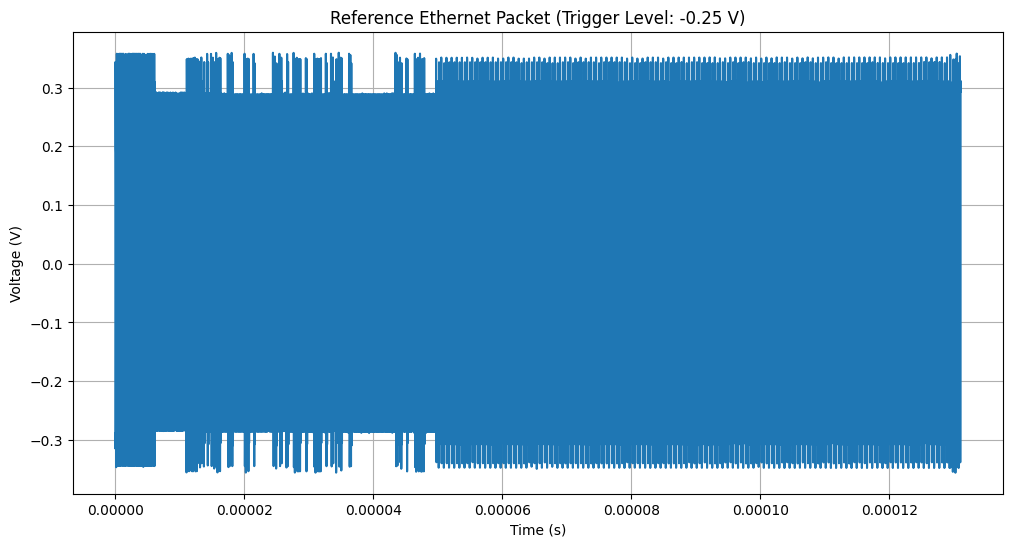

In [258]:
import matplotlib.pyplot as plt
import numpy as np

time_axis = np.arange(record_length) / sample_rate

plt.figure(figsize=(12,6))
plt.plot(time_axis, reference_packet)
plt.title(f'Reference Ethernet Packet (Trigger Level: {trigger_level} V)')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.show()

In [259]:
signal = reference_packet

In [260]:
def extract_packet(signal, threshold=0.2):
    # 1. Create boolean mask
    active = np.abs(signal) > threshold
    
    # 2. Find indices where active is True
    indices = np.where(active)[0]
    
    # 3. Handle case where no signal exceeds threshold
    if indices.size == 0:
        return np.array([]) # or return None
        
    # 4. Get start and end (add 1 to end for slicing)
    start = indices[0]
    end = indices[-1] + 1
    
    return signal[start:end]

# Usage
packet = extract_packet(signal, 0.1)

In [261]:
# import numpy as np

# # signal = your waveform
# threshold = 0.2

# active = np.abs(signal) > threshold

# start = np.argmax(active)
# end = len(signal) - np.argmax(active[::-1])

# packet = signal[start:end]

In [262]:
samples_per_bit = int(sample_rate / 10e6)  # 10Mbps
samples_per_bit

12

In [263]:
# print("Packet length (samples):", len(packet))
# print("Packet duration (s):", len(packet) / sample_rate)

# print("Packet duration (bits):", len(packet) / samples_per_bit)
# print("Packet duration (bytes):", len(packet) / (samples_per_bit * 8))
# print("Packet duration (frames):", len(packet) / (samples_per_bit * 8 * 1500))
# print("Packet duration (Ethernet frames):", len(packet) / (samples_per_bit * 8 * 1500))
# print("Start index:", start)
# print("End index:", end)

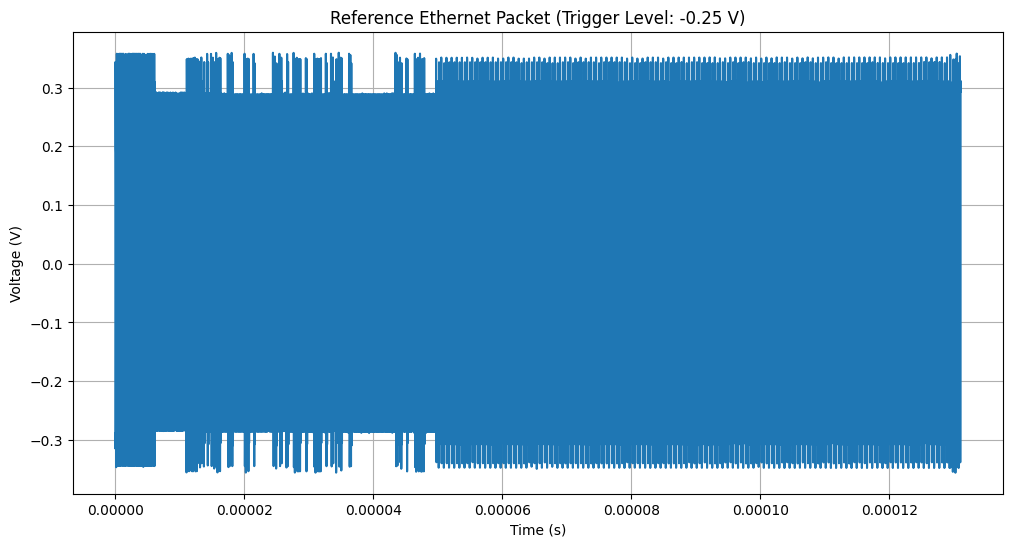

In [264]:
time_axis = np.arange(len(packet)) / sample_rate
plt.figure(figsize=(12,6))
plt.plot(time_axis, packet)
plt.title(f'Reference Ethernet Packet (Trigger Level: {trigger_level} V)')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.show()

In [265]:
packet[:200]

array([-0.289185, -0.314575, -0.268555, -0.119019,  0.052734,  0.186523,
        0.302856,  0.343628,  0.316528,  0.236084,  0.19751 ,  0.195068,
        0.192993,  0.189331,  0.157349,  0.106079, -0.012817, -0.131958,
       -0.25769 , -0.346436, -0.346436, -0.273315, -0.20105 , -0.185181,
       -0.184448, -0.182739, -0.166016, -0.126831, -0.042969,  0.089111,
        0.201904,  0.318359,  0.357544,  0.32373 ,  0.237183,  0.195923,
        0.193115,  0.19104 ,  0.185791,  0.155151,  0.105835, -0.016235,
       -0.134155, -0.256348, -0.342896, -0.344238, -0.273071, -0.200928,
       -0.185181, -0.184448, -0.181152, -0.165649, -0.126831, -0.044678,
        0.088867,  0.201904,  0.316772,  0.357178,  0.321899,  0.236938,
        0.195923,  0.191528,  0.190796,  0.185669,  0.156738,  0.10437 ,
       -0.014771, -0.133911, -0.25647 , -0.342896, -0.344238, -0.273071,
       -0.200928, -0.185181, -0.182861, -0.182617, -0.165894, -0.12854 ,
       -0.044922,  0.088867,  0.201904,  0.318359, 

In [266]:
packet[:67+125]

array([-0.289185, -0.314575, -0.268555, -0.119019,  0.052734,  0.186523,
        0.302856,  0.343628,  0.316528,  0.236084,  0.19751 ,  0.195068,
        0.192993,  0.189331,  0.157349,  0.106079, -0.012817, -0.131958,
       -0.25769 , -0.346436, -0.346436, -0.273315, -0.20105 , -0.185181,
       -0.184448, -0.182739, -0.166016, -0.126831, -0.042969,  0.089111,
        0.201904,  0.318359,  0.357544,  0.32373 ,  0.237183,  0.195923,
        0.193115,  0.19104 ,  0.185791,  0.155151,  0.105835, -0.016235,
       -0.134155, -0.256348, -0.342896, -0.344238, -0.273071, -0.200928,
       -0.185181, -0.184448, -0.181152, -0.165649, -0.126831, -0.044678,
        0.088867,  0.201904,  0.316772,  0.357178,  0.321899,  0.236938,
        0.195923,  0.191528,  0.190796,  0.185669,  0.156738,  0.10437 ,
       -0.014771, -0.133911, -0.25647 , -0.342896, -0.344238, -0.273071,
       -0.200928, -0.185181, -0.182861, -0.182617, -0.165894, -0.12854 ,
       -0.044922,  0.088867,  0.201904,  0.318359, 

In [267]:
packet = packet - np.mean(packet)

In [268]:
digital = packet > 0

In [269]:
digital[:100]

array([False, False, False, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False, False, False, False, False, False, False, False,
       False])

In [270]:
digital = digital.astype(int)

In [271]:
edges = np.where(np.diff(digital) != 0)[0]

In [272]:
edges

array([    3,    15,    28, ..., 16365, 16372, 16378], shape=(2257,))

In [273]:
edge_distances = np.diff(edges)

In [274]:
edge_distances

array([12, 13, 12, ..., 12,  7,  6], shape=(2256,))

In [275]:
bit_distance = 12.5
tolerance = 2
relevant_edges = [edges[0]]  # Start with the first edge

In [276]:
i = 0
while i < len(edge_distances):
    if abs(edge_distances[i] - bit_distance) <= tolerance:
        relevant_edges.append(edges[i+1])  # Store the index of the edge
        i += 1  # Move to next edge
    elif i+1 < len(edge_distances) and abs(edge_distances[i] + edge_distances[i+1] - bit_distance) <= tolerance:
        relevant_edges.append(edges[i+2])  # Store the index of the edge
        i += 2  # Move to the next pair of edges
    else:
        print(f"Unexpected edge distance at index {i}: {edge_distances[i]} samples")
        i += 1  # Move to next edge

In [277]:
relevant_edges[-3:]

[np.int64(16353), np.int64(16365), np.int64(16378)]

In [278]:
bits = []

for e in relevant_edges:
    if digital[e] == 0 and digital[e+1] == 1:
        bits.append(1)     # rising edge
    elif digital[e] == 1 and digital[e+1] == 0:
        bits.append(0)     # falling edge
    else:
        raise ValueError(f"Unexpected edge at index {e}: digital[{e}]={digital[e]}, digital[{e+1}]={digital[e+1]}")

In [279]:
len(bits)

1311

In [280]:
bits

[1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,


In [281]:
bits[:64]

[1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1]

In [282]:
bitstring = ''.join(map(str,bits))

idx = bitstring.find("10101010101010101010101010101010101010101010101010101011")

print("packet start bit:", idx)

packet start bit: 6


In [283]:
def find_sfd(bits):

    pattern = [1,0]*7 + [1,1]  # 10101011
    
    for i in range(len(bits)-len(pattern)):
        if bits[i:i+len(pattern)] == pattern:
            return i + len(pattern)

    return None

In [284]:
payload_start_bit = find_sfd(bits)
print("payload start bit:", payload_start_bit)

payload start bit: 62


In [285]:
start = 62

dest_bits = bits[start : start+48]
src_bits  = bits[start+48 : start+96]
type_bits = bits[start+96 : start+112]

payload_bits = bits[494 : -32]
crc_bits     = bits[-32:]

In [286]:
def bits_to_bytes(bits):
    bytes_out = []
    
    for i in range(0, len(bits), 8):
        byte = 0
        for j in range(8):
            if i + j < len(bits):
                byte = (byte << 1) | bits[i+j]
        bytes_out.append(byte)
        
    return bytes_out

In [287]:
def bits_to_bytes_lsb(bits):
    bytes_out = []
    
    for i in range(0, len(bits), 8):
        byte = 0
        for j in range(8):
            if i + j < len(bits):
                byte |= (bits[i + j] << j)  # LSB first
        bytes_out.append(byte)
    
    return bytes_out

In [288]:
dest_mac = bits_to_bytes(dest_bits)
src_mac  = bits_to_bytes(src_bits)
eth_type = bits_to_bytes(type_bits)
payload  = bits_to_bytes_lsb(payload_bits)
crc      = bits_to_bytes(crc_bits)

In [289]:
payload_bits

[0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,


In [290]:
dest_mac

[255, 255, 255, 255, 255, 255]

In [291]:
len(payload), len(payload_bits)

(99, 785)

In [292]:
payload

[120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 0]

In [293]:
samples_per_bit = int(sample_rate / 100e6)  # 100 Mbps
num_bits = len(digital) // samples_per_bit

In [294]:
payload

[120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 120,
 0]